# RAW EEG Temporal analysis: MDD VS Healthy Controls

This notebook documents the exploratory workflow used to compare depression-related EEG structure across patients. 

The goal is not only to train a classifier, but to understand which EEG representation is most useful:

1. Segment raw EEG recordings into fixed-length time windows. 
2. Extract Welch band-power features from each segment for temporal ablation. 
3. Evaluate classical ML models using patient-level GroupKFold. 
4. Explore temporal ablation to test whether specific time windows are especially important.
5. Compare Welch feautures against raw-signal models, including CNN-based approaches. 


## 1. Imports and Configuration 

In [137]:
import os
import json 
from pathlib import Path 
from collections import Counter 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
import umap
import tensorflow as tf

from sklearn.model_selection import GroupKFold, cross_validate, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D, 
    GlobalAveragePooling1D,
    Dense, 
    Dropout,
    LSTM,
    Concatenate,
    Activation
)
from tensorflow.keras.optimizers import Adam


In [138]:
# Reproducibility 
RANDOM_STATE = 42
N_SPLITS = 5

# Set to True onlu when you want to rerun the expensive TensorFlow models.
RUN_DEEP_MODELS = False

# EEG channels standardized across recordings
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

# Frequency bands used for Welch band-power features 
BANDS = {
    'delta': (1,4),
    'theta': (4,8),
    'alpha': (8,13),
    'beta': (13,30)
}

In [139]:
def find_project_root():
    """ Find the project root by locating .git directory."""
    p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()

    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
        
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()

# Base directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw" / "nm000114"
SEGMENTED_DATA_DIR = DATA_DIR / "segmented_data"

RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"

# Ensure directories exist
SEGMENTED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Result Catching Helpers 

The deep-learning cells below use cache files in results/tables/deep_learning_cache/.

- If RUN_DEEP_MODELS = False, the notebook loads saved metrics when they exist.
- If a cache file does not exist, the notebook will train the model once and save the results.
- If Run_DEEP_MODELS = True, the notebook retrains and overwrites the cache. 

This keeps the notebook reproducible without requiring every CNN/LSTM model to retrain each time. 

In [140]:
# Cache setup for expensive deep-learning experiments 

CACHE_DIR = RESULTS_DIR / "tables" / "deep_learning_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _summary_to_dataframe(result_dict, model_name, window_sec=10, notes=""):
    """Convert the top-level metric from a result dictionary into a one-row DataFrame"""
    return pd.DataFrame([{
        "model_name": model_name,
        "window_sec": window_sec,
        "accuracy": float(result_dict["accuracy"]),
        "f1": float(result_dict["f1"]),
        "roc_auc": float(result_dict["roc_auc"]),
        "n_folds": len(result_dict.get("fold_results", [])) or N_SPLITS,
        "notes": notes
    }])

def save_model_cache(result_dict, model_key, model_name, window_sec=10, notes=""):
    """
    Save model-level metrics, fold-level metric, and training histories.
    
    Files created:
    - <model_key>_summary.csv
    - <model_key>_folds.csv
    - <model_key>_histories.json, when histories are available
    """
    summary_path = CACHE_DIR / f"{model_key}_summary.csv"
    folds_path = CACHE_DIR / f"{model_key}_folds.csv"
    histories_path = CACHE_DIR / f"{model_key}_histories.json"

    summary_df = _summary_to_dataframe(result_dict, model_name, window_sec, notes)
    summary_df.to_csv(summary_path, index=False)

    if "fold_results" in result_dict:
        result_dict["fold_results"].to_csv(folds_path, index=False)

    if "histories" in result_dict:
        with open(histories_path, "w") as f:
            json.dump(result_dict["histories"], f)

    print(f"Saved cache for {model_name}:")
    print(" ", summary_path)
    print(" ", folds_path)
    if "histories" in result_dict:
        print(" ", histories_path)

def load_model_cache(model_key):
    """ Load cached model-level metrics, fold-level metrics, and histories if available."""
    summary_path = CACHE_DIR / f"{model_key}_summary.csv"
    folds_path = CACHE_DIR / f"{model_key}_folds.csv"
    histories_path = CACHE_DIR / f"{model_key}_histories.json"

    if not summary_path.exists() or not folds_path.exists():
        return None
    
    summary_df = pd.read_csv(summary_path)
    folds_df = pd.read_csv(folds_path)

    result_dict = {
        "accuracy": float(summary_df.loc[0, "accuracy"]),
        "f1": float(summary_df.loc[0, "f1"]),
        "roc_auc": float(summary_df.loc[0, "roc_auc"]),
        "fold_results": folds_df,
    }

    if histories_path.exists():
        with open(histories_path, "r") as f:
            result_dict["histories"] = json.load(f)

    print(f"Loaded cached results for {model_key}")
    return result_dict

def run_or_load_model(model_key, model_name, train_function, X, y, groups,
                      window_sec=10, notes="", n_splits=5, epochs=10, batch_size=32):
    """
    Load cached results unless RUN_DEEP_MODELS=True or the cache does not exist.
    If training is required, run the model and save the result cache.
    """
    cached = None if RUN_DEEP_MODELS else load_model_cache(model_key)

    if cached is not None:
        return cached

    print(f"Training {model_name} because cache was missing or RUN_DEEP_MODELS=True.") 
    result = train_function(
        X,
        y, 
        groups,
        n_splits=n_splits,
        epochs=epochs, 
        batch_size=batch_size
    )

    save_model_cache(
        result, 
        model_key=model_key,
        model_name=model_name,
        window_sec=window_sec,
        notes=notes
    )
    return result

def summarize_cache_result(result_dict, label):
    """Print a consistent summary and return the fold-level DataFrame. """
    print(f"\n{label} mean accuracy:", result_dict["accuracy"])
    print(f"{label} mean F1:", result_dict["f1"])
    print(f"{label} mean ROC-AUC:", result_dict["roc_auc"])
    return result_dict["fold_results"]

def build_deep_model_comparison(results_map, output_name="deep_model_comparison.csv"):
    """Combine cached deep-learning summary files into one comparison table."""
    rows = []

    for model_key, display_name in results_map.items():
        summary_path = CACHE_DIR / f"{model_key}_summary.csv"

        if summary_path.exists():
            row = pd.read_csv(summary_path).iloc[0].to_dict()
            row["method"] = display_name
            rows.append(row)
        else:
            print(f"Missing cache for {display_name}: {summary_path}")

    comparison = pd.DataFrame(rows)

    if not comparison.empty:
        cols = [
            "method",
            "model_name",
            "window_sec",
            "accuracy", 
            "f1",
            "roc_auc",
            "n_folds",
            "notes",
        ]

        comparison = comparison[[c for c in cols if c in comparison.columns]]
        comparison.to_csv(RESULTS_DIR / "tables" / output_name, index=False)
    return comparison 

## 2. Build Recording Metadata 

Each EDF file is mapped to patient ID, recording ID, diagnostic label, condition, and filepath. 

Labels:

- 0 = healthy control 
- 1 = MDD 

This metadata table is important becuase cross-validation will be grouped by patient_id to prevent patient leakage. 

In [141]:
def infer_label_from_subject(subject_id: str) -> int:
    """Infer label: 0 = healthy control, 1 = MDD."""
    subject_upper = subject_id.upper()

    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
     
    raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """Parse condition from EDF filename."""
    name = filepath.name 

    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    
    raise ValueError(f"Could not parse condition from filename: {name}")
        
edf_files =sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))
        
rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3] 

    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })


metadata_df = pd.DataFrame(rows)
metadata_df.head()        

,patient_id,recording_id,label,condition,filepath
0,sub-HS1,sub-HS1_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
1,sub-HS1,sub-HS1_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...
2,sub-HS1,sub-HS1_task-P300_eeg,0,P300,d:\eeg-mdd-classification\data\raw\nm000114\su...
3,sub-HS10,sub-HS10_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
4,sub-HS10,sub-HS10_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...


In [142]:
print("Shape:", metadata_df.shape)

print("\nUnique patients:", metadata_df["patient_id"].nunique())

print("\nClass counts:")
display(metadata_df["label"].value_counts().rename({0: "Healthy", 1: "MDD"}))

print("\nCondition counts:")
display(metadata_df["condition"].value_counts())


Shape: (181, 5)

Unique patients: 64

Class counts:


label
MDD        95
Healthy    86
Name: count, dtype: int64


Condition counts:


condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64

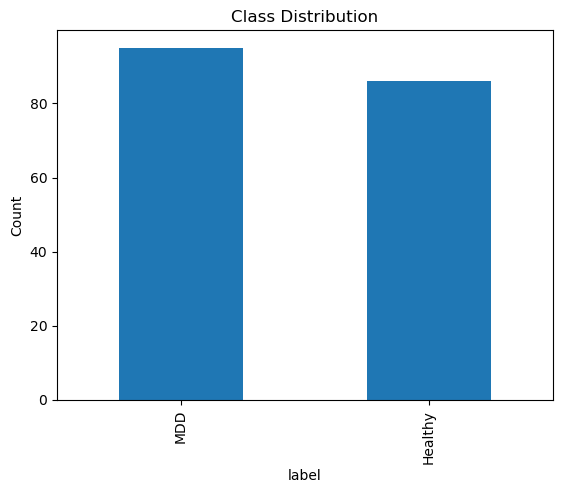

In [143]:
metadata_df["label"].value_counts().rename({0: "Healthy", 1: "MDD"}).plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

## 3. Exploratory Segmentation Check 

Before building the full dataset, test segmentation on one recording. This confirms that the EDF files loads correctly, the common EEG channels are present, and fixed-length windows are created as expected. 

In [144]:
test_path = metadata_df.loc[0, "filepath"]

raw_test = mne.io.read_raw_edf(test_path, preload=True, verbose=False) 
raw_test.pick(COMMON_CHANNELS)

# create fixed-length epochs (5-second windows)
window_sec = 5.0 
epochs_test = mne.make_fixed_length_epochs(
    raw_test,
    duration=window_sec,
    preload=True,
    overlap=0.0,
    verbose=False,
)

raw_data = raw_test.get_data()
epoch_data = epochs_test.get_data()

print("File", Path(test_path).name)
print("Raw shape (channels, timepoints):", raw_data.shape)
print("Epoch shape (segments, channels, timepoints):", epoch_data.shape)
print("Sampling frequency:", raw_test.info["sfreq"])
print("Segments created:", len(epoch_data))

File sub-HS1_task-eyesClosed_eeg.edf
Raw shape (channels, timepoints): (20, 76800)
Epoch shape (segments, channels, timepoints): (60, 20, 1280)
Sampling frequency: 256.0
Segments created: 60


An initial exploratory analysis was performed to evalaute the impact of segmentation window size on the structure of the EEG data. Using 2-second windows, each recording was divided into approximately 150 segments, with each segment containing 20 channels and 512 timepoints, consistent with a sampling frequency of 256 Hz. While this approach increased the number of training samples, the short window length provided limited frequency resolution, making it less suitable for stable estimation of band-power features using Welch's method.

To address this limitation, the window size was increased to 5 seconds. This resulted in fewer segments per recording (approximately 60), but each segment contained more temporal information (1280 time points), improving frequency resolution and feature stability.

Based on this analysis, the final segmentation approach used fixed-length windows of 5 seconds, with signals standardized to 20 common EEG channels. This configuration provides a balance between sample size and spectral feature quality, ensuring reliable extraction of band-power features while maintaining sufficient training data.  

## 4. Welch Band-Power Feature Extraction 

For each EEG segment, Welch's method estimates power spectral density from 1-30 Hz. The final feature vector has:

20 channels x 4 frequency bands = 80 features 

Band-power features are normalized by total power to reduce differences caused by overall signal amplitude. 

In [145]:
def extract_band_power_from_array(epoch_data, sfreq, bands=BANDS):
    """ 
    Extract relative Welch band-power features from one EEG window.

    Parameters
    ---------
    epoch_data: np.ndarray
        Shape: (n_channels, n_timepoints)
    sfreq: float
        Sampling frequency. 
    bands: dict 
        Frequency-band definitions. 

    Returns
    -------
    np.ndarray
      Flatten feature vector with shape (n_channels * n_bands).
    """
    all_features = []

    for ch in epoch_data:
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            n_fft=min(len(ch), 256),   # use smaller n_fft for short windows
            n_per_seg=min(len(ch), 256),
            verbose=False
        )

        total_power = psd.sum()

        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean() / total_power
                if total_power > 0 else 0 
            )
            for (fmin, fmax) in bands.values()
        ]

        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())

# sanity check on one epoch 
epoch_array = epochs_test.get_data()[0]
features_test = extract_band_power_from_array(epoch_array, epochs_test.info['sfreq'])

print("Feature vector shape:", features_test.shape)

Feature vector shape: (80,)


## 5. Build and Cache Segmented Welch Datasets 

The full dataset is expensive to rebuild, so the final helper functions save and reload segmented arrays. 

Each returned dataset contains: 

- X_seg: Welch feature matrix
- y_seg: binary diagnostic labels
- groups_seg: patients IDs for grouped cross-validation
- seg_df: metadata for each segment, including segment_idx

In [146]:
def build_segmented_dataset(metadata_df, common_channels, window_sec):
    """ Build segmented Welch band-power features from all EDF recordings."""
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []
    recording_ids = []
    segmented_indices = []

    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data()
        sfreq = epochs.info["sfreq"]

        for i in range(len(epoch_data)):
            features = extract_band_power_from_array(epoch_data[i], sfreq)

            X_segments.append(features)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")
            recording_ids.append(row["recording_id"])
            segmented_indices.append(i)

    X_segments = np.vstack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    segmented_df = pd.DataFrame({
        "recording_id": recording_ids,
        "recording_segment": recording_segments,
        "patient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments,
        "segment_idx": segmented_indices
    })

    return X_segments, y_segments, groups_segments, segmented_df

def save_segmented_data(X, y, groups, seg_df, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Save segmented arrays and metadata to disk"""
    save_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"{int(window_sec)}sec"

    np.save(save_dir / f"X_seg_{suffix}.npy", X)
    np.save(save_dir / f"y_seg_{suffix}.npy", y)
    np.save(save_dir / f"groups_seg_{suffix}.npy", groups)
    seg_df.to_csv(save_dir / f"seg_df_{suffix}.csv", index=False)

def load_segmented_data(window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load segmented arrays and metadata from disk."""
    suffix = f"{int(window_sec)}sec"

    X = np.load(save_dir /  f"X_seg_{suffix}.npy")
    y = np.load(save_dir / f"y_seg_{suffix}.npy")
    groups = np.load(save_dir / f"groups_seg_{suffix}.npy")
    seg_df = pd.read_csv(save_dir / f"seg_df_{suffix}.csv")

    return X, y, groups, seg_df


def get_or_build_segmented_data(metadata_df, common_channels, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load cached segmented data if available; otherwise build and save it."""
    suffix = f"{int(window_sec)}sec"
    X_path = save_dir / f"X_seg_{suffix}.npy"

    if X_path.exists():
        print(f"Loading cached data for {window_sec}s...")
        return load_segmented_data(window_sec, save_dir=save_dir)
    
    print(f"Building segmented data for {window_sec}s...")
    X, y, groups, seg_df = build_segmented_dataset(
        metadata_df, 
        common_channels,
        window_sec=window_sec
    )

    save_segmented_data(X, y, groups, seg_df, window_sec, save_dir=save_dir)

    return X, y, groups, seg_df 

In [147]:
# Final feature datasets used in the main analysis
X_seg_5, y_seg_5, groups_seg_5, seg_df_5 = get_or_build_segmented_data(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=5.0
)

X_seg_10, y_seg_10, groups_seg_10, seg_df_10 = get_or_build_segmented_data(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=10.0
)

print("5-sec Welch feature shape:", X_seg_5.shape)
print("10-sec Welch feature shape:", X_seg_10.shape)

print("\nUnique patients (10-sec):", len(np.unique(groups_seg_10)))
print("Total segments (10-sec):", len(X_seg_10))

Loading cached data for 5.0s...
Loading cached data for 10.0s...
5-sec Welch feature shape: (14743, 80)
10-sec Welch feature shape: (7339, 80)

Unique patients (10-sec): 64
Total segments (10-sec): 7339


## 6. Classical Model Evaluation 

The primary classical model is an SVM with an RBF kernel. Logistic regression is included as a simpler baseline. 

Important design choice: GroupKFold is grouped by patient ID. This prevents EEG windows from the same patient appearing in both train and test folds. 

In [148]:
gkf = GroupKFold(n_splits=N_SPLITS)

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "SVM RBF":  Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
}

def evaluate_sklearn_model(model, X, y, groups, cv=gkf):
    """ Evaluate a scikit-learn model using grouped cross-validation."""
    scores = cross_validate(
        model, 
        X,
        y, 
        groups=groups,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"]
    )

    return {
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "n_folds": cv.get_n_splits(),
    }

In [149]:
WELCH_RESULTS_PATH = RESULTS_DIR / "tables" / "welch_window_size_results.csv"
WELCH_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if WELCH_RESULTS_PATH.exists():
    print("Loading cached Welch window results...")
    window_results_df = pd.read_csv(WELCH_RESULTS_PATH)

else:
    print("Running Welch window experiments...")

    window_results = []

    for window_sec, X, y, groups in [
        (5.0, X_seg_5, y_seg_5, groups_seg_5),
        (10.0, X_seg_10, y_seg_10, groups_seg_10)
    ]:
        for model_name, model in models.items():
            scores = evaluate_sklearn_model(model, X, y, groups)
        
            window_results.append({
                "window_sec": window_sec,
                "model_name": model_name,
                "accuracy": scores["accuracy"],
                "f1": scores["f1"],
                "roc_auc": scores["roc_auc"],
                "n_folds": scores["n_folds"],
                "notes": "Welch relative band-power features with GroupKFold",
            })

    window_results_df = pd.DataFrame(window_results)

    window_results_df = window_results_df.rename(columns={
        "roc-auc": "roc_auc",
        "n-folds": "n_folds"
    })
    
    window_results_df = window_results_df.sort_values(
        by=["window_sec", "roc_auc"],
        ascending=[True, False]
    ).reset_index(drop=True)
    
    window_results_df.to_csv(WELCH_RESULTS_PATH, index=False)

window_results_df 

Loading cached Welch window results...


,window_sec,model_name,accuracy,f1,roc_auc,n_folds,notes
0,5.0,SVM RBF,0.798763,0.812561,0.889488,5,Welch relative band-power features with GroupK...
1,5.0,LogisticRegression,0.777606,0.792486,0.878635,5,Welch relative band-power features with GroupK...
2,10.0,SVM RBF,0.827231,0.844465,0.908115,5,Welch relative band-power features with GroupK...
3,10.0,LogisticRegression,0.801850,0.810668,0.884826,5,Welch relative band-power features with GroupK...


### Interpretation:

The 10-sec windows consistently outperformed the 5-second windows across both Logistic Regression and SVM models, with improvements observed in acccuracy(~2-3%), F1-score, and ROC-AUC. This suggests that depression -related spectral patterns are more reliably captured when the model has access to longer temporal segments. 

This finding aligns with the properties of Welch power spectral density estimation, where longer windows provide improved frequency resolution and reduce variance in spectral estimates. Although shorter windows increase the number of training samples, they may introduce instability in band-power features due to limited temporal context.

Overall, the results support the use of 10-second windows as a more effective configuration for feature-based EEG classification, providing a favorable tradeoff between data quantity and feature quality. 

This observation also motivates the use of longer temporal windows in subsequent deep learning models, where temporal context may further enhance performance. 

In [150]:
# Classical Welch baselines (10-sec window)

classical_results_df = window_results_df.query("window_sec == 10").copy()

# Add method label for later merging 
classical_results_df["method"] = "Welch + Classical ML"

# Save 
classical_results_df.to_csv(RESULTS_DIR / "tables" / "classical_welch_results.csv", index=False)


classical_results_df 

,window_sec,model_name,accuracy,f1,roc_auc,n_folds,notes,method
2,10.0,SVM RBF,0.827231,0.844465,0.908115,5,Welch relative band-power features with GroupK...,Welch + Classical ML
3,10.0,LogisticRegression,0.801850,0.810668,0.884826,5,Welch relative band-power features with GroupK...,Welch + Classical ML


 ## 7. Temporal Ablation  

The next exploratory questions is:

Are certain time segments more important than others?

To test this, one segment index is removed at a time, and the SVM is re-evaluated. If removing a specific segment causes a large performance drop, that part of the recording may contain especially useful signal.

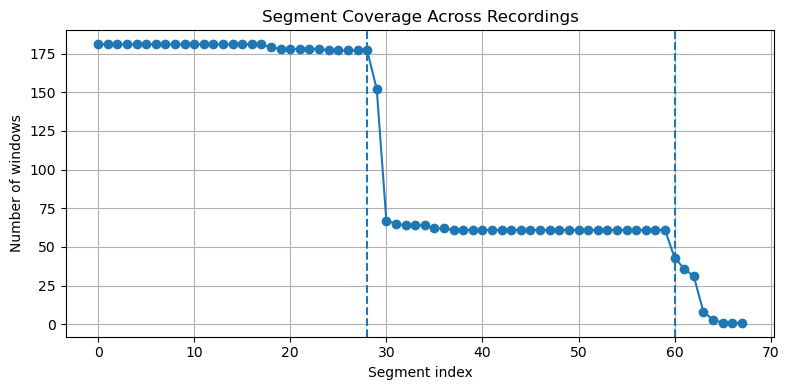

Max_coverage: 181
Min coverage: 1
Segments with full coverage: 18


In [151]:
segment_counts = seg_df_10["segment_idx"].value_counts().sort_index()

plt.figure(figsize=(8,4))
segment_counts.plot(marker="o")

plt.xlabel("Segment index")
plt.ylabel("Number of windows")
plt.title("Segment Coverage Across Recordings")

# Key visual guides
plt.axvline(28, linestyle="--")     # stable region cutoff
plt.axvline(60, linestyle="--")     # collapse region start

plt.grid(True)
plt.tight_layout()
plt.show()

print("Max_coverage:", segment_counts.max())
print("Min coverage:", segment_counts.min())
print("Segments with full coverage:", (segment_counts == segment_counts.max()).sum())

The segmented coverage analysis reveals a clear imbalance in the number of available samples across temporal segments. Early segment indices (approximately 0-28) exhibit consistently high coverage, with around 180 samples per segment, making this region the most reliable for analysis.

A sharp drop in coverage occurs around segment indices 29-30, where the number of samples decreases substantially to approximately 60-70. Beyond this point, a plateau region persists (approximately 30-58) with moderate but reduced coverage.

At later segment indices (~60 and above), coverage declines rapidly toward zero, indicating that only a small subset of recordings contribute to these segments. As a result, these regions are highly underrepresented and prone to noise.

Due to this uneven distribution, the temporal ablation analysis was restricted to the well-covered early segment range (0-28), ensuring that performance changes reflect meaningful temporal effects rather than artifacts of limited sample size. 

In [152]:
def run_temporal_ablation(
    X_seg,
    y_seg,
    groups_seg,
    seg_df,
    model,
    cv,
    valid_segments=None
):
    """
    Remove one segment index at a time and evaluate the change in performance.
    """

    if "segment_idx" not in seg_df.columns:
        raise ValueError("seg_df must contain a 'segment_idx' column")
    
    seg_df = seg_df.copy()
    seg_df["segment_idx"] = seg_df["segment_idx"].astype(int)

    baseline = cross_validate(
        model,
        X_seg,
        y_seg,
        groups=groups_seg,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"]
    )

   
    baseline_acc = baseline["test_accuracy"].mean()
    baseline_f1 =  baseline["test_f1"].mean()
    baseline_auc = baseline["test_roc_auc"].mean()
    

    if valid_segments is None:
        valid_segments = sorted(seg_df["segment_idx"].unique())

    results = []

    for seg_idx in valid_segments:
        keep_mask = seg_df["segment_idx"].to_numpy() != seg_idx

        X_ablate = X_seg[keep_mask]
        y_ablate = y_seg[keep_mask]
        groups_ablate = groups_seg[keep_mask]

        scores = cross_validate(
            model,
            X_ablate,
            y_ablate,
            groups=groups_ablate,   
            cv=cv,
            scoring=["accuracy", "f1", "roc_auc"]
        )
        
        acc = scores["test_accuracy"].mean()
        f1 = scores["test_f1"].mean()
        auc = scores["test_roc_auc"].mean()

        results.append({
            "ablated_segment": seg_idx,
            "n_samples_remaining": X_ablate.shape[0],
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc,
            "delta_accuracy": acc - baseline_acc,
            "delta_f1": f1 - baseline_f1,
            "delta_roc_auc": auc - baseline_auc
        })

    baseline_df = pd.DataFrame([{
        "ablated_segment": "baseline",
        "n_samples_remaining": X_seg.shape[0],
        "accuracy": baseline_acc,
        "f1": baseline_f1,
        "roc_auc": baseline_auc,
        "delta_accuracy": 0.0,
        "delta_f1": 0.0,
        "delta_roc_auc": 0.0
    }])

    ablation_df = pd.DataFrame(results)

    return baseline_df, ablation_df

In [153]:
ABLATION_PATH = RESULTS_DIR / "tables" / "temporal_ablation_10sec.csv"
BASELINE_PATH = RESULTS_DIR / "tables" / "baseline_ablation_10sec.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if ABLATION_PATH.exists() and BASELINE_PATH.exists():
    print("Loading cached ablation results...")

    ablation_results_df = pd.read_csv(ABLATION_PATH)
    baseline_ablation_df = pd.read_csv(BASELINE_PATH)

else:
    print("Running temporal ablation...")

    segment_counts = seg_df_10["segment_idx"].value_counts().sort_index()
    VALID_SEGMENTS = segment_counts[segment_counts > 150].index.tolist()

    baseline_ablation_df, ablation_results_df = run_temporal_ablation(
        X_seg_10,
        y_seg_10,
        groups_seg_10,
        seg_df_10,
        model=models["SVM RBF"],
        cv=gkf,
        valid_segments=VALID_SEGMENTS
    )

    # save results
    ablation_results_df.to_csv(ABLATION_PATH, index=False)
    baseline_ablation_df.to_csv(BASELINE_PATH, index=False)

ablation_results_df.head()

Loading cached ablation results...


,ablated_segment,n_samples_remaining,accuracy,f1,roc_auc,delta_accuracy,delta_f1,delta_roc_auc
0,0,7158,0.825841,0.842266,0.905412,-0.001390,-0.002200,-0.002703
1,1,7158,0.825866,0.842548,0.904435,-0.001365,-0.001918,-0.003680
2,2,7158,0.824530,0.841551,0.906052,-0.002701,-0.002914,-0.002064
3,3,7158,0.823974,0.840201,0.905304,-0.003257,-0.004265,-0.002812
4,4,7158,0.822984,0.839972,0.904258,-0.004247,-0.004493,-0.003857


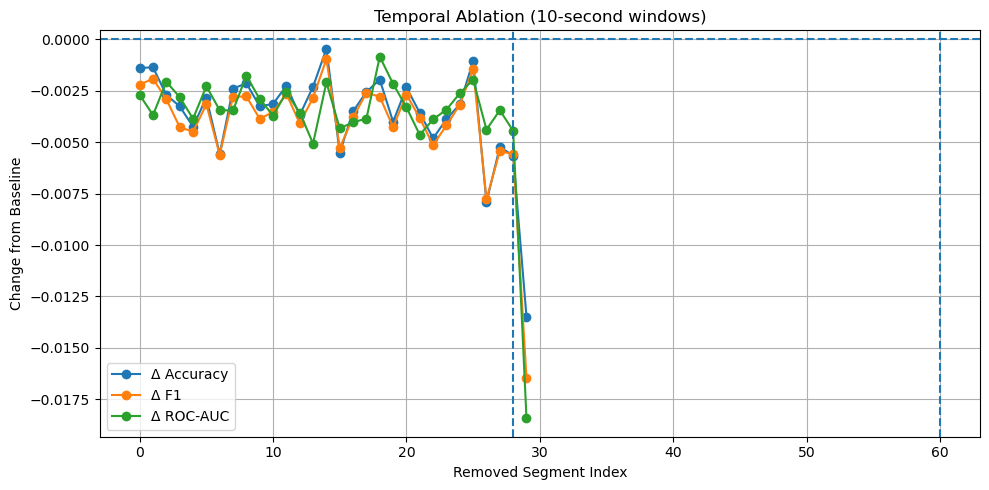

In [154]:
plt.figure(figsize=(10,5))

ablation_results_df.plot(
    x="ablated_segment",
    y=["delta_accuracy", "delta_f1", "delta_roc_auc"],
    marker='o',
    ax=plt.gca()
)

# Baseline reference
plt.axhline(0, linestyle="--")

# Highlight important regions (based on coverage analysis)
plt.axvline(28, linestyle="--")
plt.axvline(60, linestyle="--")

plt.xlabel("Removed Segment Index")
plt.ylabel("Change from Baseline")
plt.title("Temporal Ablation (10-second windows)")

plt.legend(["Δ Accuracy", "Δ F1", "Δ ROC-AUC"])

plt.grid(True)
plt.tight_layout()
plt.show()

A temporal ablation study was conducted by removing individual segments from 10-second EEG windows and evaluating the resulting change in model performance. 

For most segments, removal resulted in only minor decreases in accuracy, F1-score, and ROC-AUC, indicating that the model is robust to the exclusion of individual temporal regions. This suggests that discriminative information is broadly distributed across the signal rather than concentrated in a single segment.

However, segments toward the end of the window produced noticeably larger performance drops when removed. This may reflect boundary effects, reduced signal stability, or uneven information distribution in later portions of the recording. 

Overall, these results indicate that while temporal structure contributes to classification performance, the model does not rely heavily on any single segment, supporting a distributed representation of relevant EEG features. 

## 8. Feature-Space Exploration: PCA, UMAP, and GMM

The next exploratory step asks whether the feature space itself shows structure. PCA gives a linear projection, while UMAP gives a nonlinear projection. GMM is then used to test whether unsupervised clusters roughly align with labels. 

Explained variance: [0.53077155 0.23748297]
Total explained variance: 0.7682545245377299


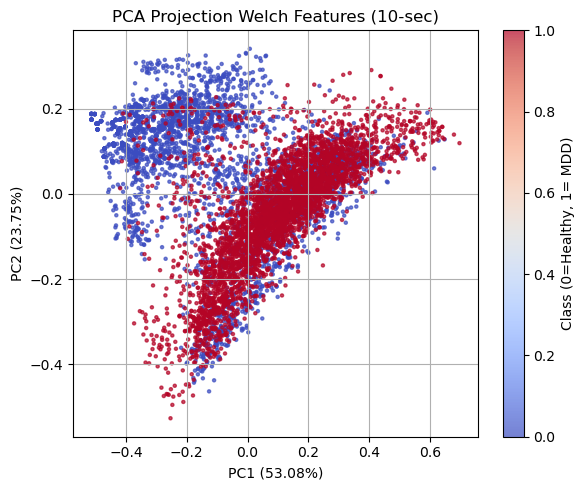

In [155]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_seg_10)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(6,5))

scatter= plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_seg_10,
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA Projection Welch Features (10-sec)")

cbar = plt.colorbar(scatter)
cbar.set_label("Class (0=Healthy, 1= MDD)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation 

PCA shows that while there is some separation between MDD and healthy subjects along the principal components, the classes are highly overlapping. This indicates that the extracted EEG features contain meaningful signal, but the separation is not linearly clean, which motivates the use of non-linear models such as SVM. 

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


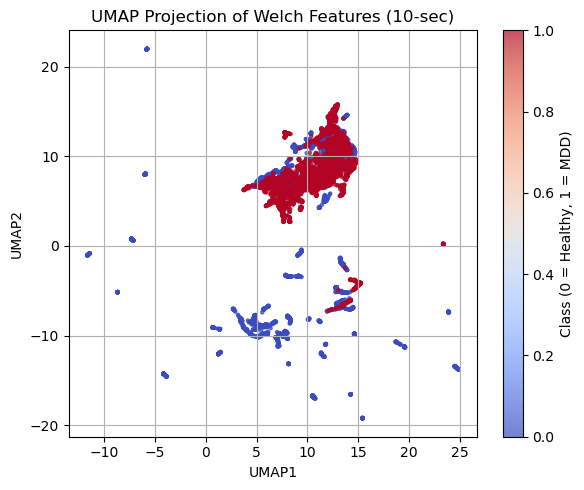

In [156]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

X_umap = umap_model.fit_transform(X_seg_10)

# plot UMAP results 
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y_seg_10,
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2") 
plt.title("UMAP Projection of Welch Features (10-sec)")

cbar = plt.colorbar(scatter)
cbar.set_label("Class (0 = Healthy, 1 = MDD)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation:

UMAP projection reveals meaningful structure in the Welch feature space, with partial separation between MDD and Healthy samples. MDD samples tend to cluster in a dense upper region, while healthy samples are more prevalent in a separate lower region. 

However, the overlap between classes indicates that the separation is not clean, suggesting that while class-related patterns exist, they are not linearly separable and require nonlinear or supervised models for effective classification. 

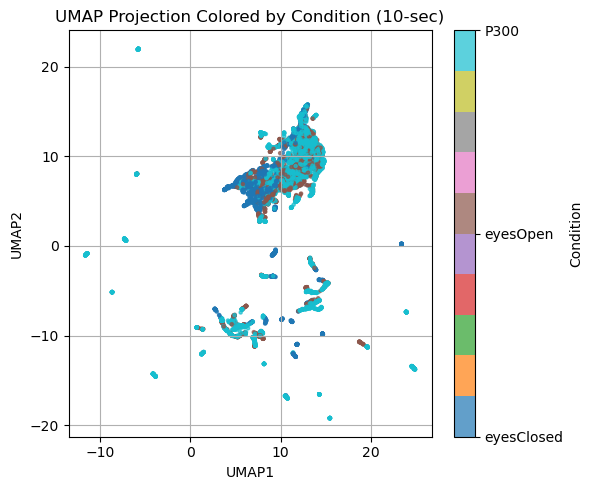

In [157]:
condition_map = {
    "eyesClosed": 0,
    "eyesOpen": 1,
    "P300": 2
}

# color by condition code 
colors = seg_df_10["condition"].map(condition_map)

plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=colors,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2") 
plt.title("UMAP Projection Colored by Condition (10-sec)")

cbar = plt.colorbar(scatter)
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(["eyesClosed", "eyesOpen", "P300"])
cbar.set_label("Condition")

plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation:

UMAP colored by experimental condition shows no clear separation between eyesClosed, eyesOpen, and P300 recordings. Instead, conditions are mixed within the same regions of the embedding. 

This indicates that the dominant structure in the feature space is not driven by task condition. Therefore, the patterns learned by the models are unlikely to be explained by condition-specific artifacts and are more likely to reflect underlying  disease-related differences. 



GMM clustering consistency: 0.790971495335393


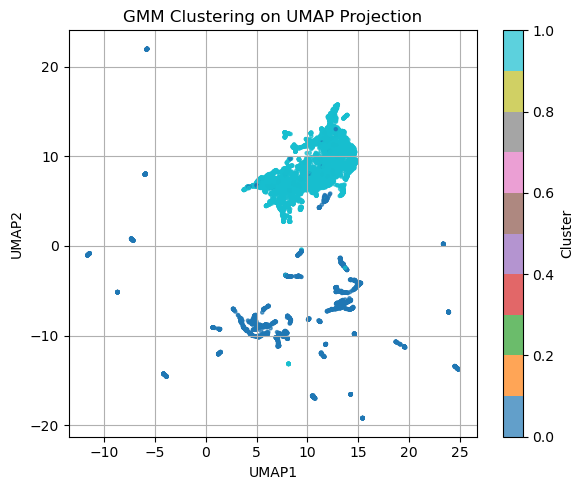

In [158]:
from collections import Counter
from sklearn.mixture import GaussianMixture

def clustering_accuracy(y_true, y_pred):
    """"
    Estimate clustering consistency by matching each true class
    to its dominant predicted cluster.

    Note: Not true classification accuracy.
    """
    accs = []

    for true_label in np.unique(y_true):
        mask = (y_true == true_label)

        dominant_cluster = Counter(y_pred[mask]).most_common(1)[0][0]
        accs.append(np.mean(y_pred[mask] == dominant_cluster))
        
    return np.mean(accs)

gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_seg_10)

print("GMM clustering consistency:", clustering_accuracy(y_seg_10, gmm_labels))

plt.figure(figsize=(6,5))

scatter= plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=gmm_labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.title("GMM Clustering on UMAP Projection")
plt.xlabel("UMAP1") 
plt.ylabel("UMAP2")

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation 

Clustering consistency: 0.79

Gaussian Mixture Modeling achieved approximately 0.79 clustering consistency, indicating that the extracted EEG features contain meaningful structure that partially aligns with diagnostic labels, even without supervision.

Overall:

EEG-derived band-power features contain structured information related to depression. While this structure is not linearly separable (as shown by PCA), it becomes more apparent in nonlinear representations (UMAP). The moderate clustering consistency suggests that class-related patterns exist in the feature space, but are not cleanly separable, motivating the use of supervised and nonlinear models for improved classification. 

## 9. Raw EEG Comparison   

Welch features summarize frequency content. To compare against less-engineered representation, the next section uses raw 10-second EEG windows.

The raw windows are evaluated in two ways:

1. Flattened raw signal + PCA + SVM
2. Raw signal deep-learning models

In [159]:
def build_raw_segmented_dataset(metadata_df, common_channels, window_sec=10.0):
    """ Build raw EEG windows without Welch feature extraction."""
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []
    segment_indices = []
        
    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data() 

        for i, segment in enumerate(epoch_data):
            X_segments.append(segment)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")
            segment_indices.append(i)

    X_segments = np.stack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    raw_seg_df = pd.DataFrame({
        "recording_segment": recording_segments,
        "patient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments,
        "segment_idx": segment_indices
    })

    return X_segments, y_segments, groups_segments, raw_seg_df

def save_raw_segmented_data(X, y, groups, seg_df, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Save raw segmented EEG data to disk."""
    save_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"{int(window_sec)}sec"

    np.save(save_dir / f"X_raw_{suffix}.npy", X)
    np.save(save_dir / f"y_raw_{suffix}.npy", y)
    np.save(save_dir / f"groups_raw_{suffix}.npy", groups)
    seg_df.to_csv(save_dir / f"raw_seg_df_{suffix}.csv", index=False)

def load_raw_segmented_data(window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load cached raw segmented EEG data."""
    suffix = f"{int(window_sec)}sec"

    X = np.load(save_dir / f"X_raw_{suffix}.npy")
    y = np.load(save_dir / f"y_raw_{suffix}.npy")
    groups = np.load(save_dir / f"groups_raw_{suffix}.npy")
    seg_df = pd.read_csv(save_dir / f"raw_seg_df_{suffix}.csv")

    return X, y, groups, seg_df

def get_or_build_raw_segmented_data(metadata_df, common_channels, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load cached raw EEG segments if available; otherwise build and save."""
    suffix = f"{int(window_sec)}sec"
    X_path = save_dir / f"X_raw_{suffix}.npy"

    if X_path.exists():
        print(f"Loading cached raw data for {window_sec}s...")
        return load_raw_segmented_data(window_sec, save_dir=save_dir)
    
    print(f"Building raw segmented data for {window_sec}s...")
    X, y, groups, raw_seg_df = build_raw_segmented_dataset(
        metadata_df,
        common_channels,
        window_sec=window_sec
    )

    save_raw_segmented_data(X, y, groups, raw_seg_df, window_sec, save_dir=save_dir)

    return X, y, groups, raw_seg_df

In [160]:
X_raw_10, y_raw_10, groups_raw_10, raw_seg_df_10 = get_or_build_raw_segmented_data(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=10.0
)

print("Raw segmented X shape:", X_raw_10.shape)
print("Raw segmented y shape:", y_raw_10.shape) 
print("Unique patients:", len(np.unique(groups_raw_10)))
raw_seg_df_10.head()

Loading cached raw data for 10.0s...
Raw segmented X shape: (7339, 20, 2560)
Raw segmented y shape: (7339,)
Unique patients: 64


,recording_segment,patient_id,label,condition,segment_idx
0,sub-HS1_task-eyesClosed_eeg_seg0,sub-HS1,0,eyesClosed,0
1,sub-HS1_task-eyesClosed_eeg_seg1,sub-HS1,0,eyesClosed,1
2,sub-HS1_task-eyesClosed_eeg_seg2,sub-HS1,0,eyesClosed,2
3,sub-HS1_task-eyesClosed_eeg_seg3,sub-HS1,0,eyesClosed,3
4,sub-HS1_task-eyesClosed_eeg_seg4,sub-HS1,0,eyesClosed,4


In [161]:
RAW_PCA_PATH = RESULTS_DIR / "tables" /  "raw_pca_svm_10sec.csv"
RAW_PCA_PATH.parent.mkdir(parents=True, exist_ok=True)

if RAW_PCA_PATH.exists():
    print("Loading cached RAW PCA + SVM results...")
    raw_pca_df = pd.read_csv(RAW_PCA_PATH)

else:
    print("Running RAW PCA + SVM...")

    # flatten raw segments for modeling
    X_raw_10_flat = X_raw_10.reshape(X_raw_10.shape[0], -1)

    pipeline_raw_pca_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ])

    scores = evaluate_sklearn_model(
        pipeline_raw_pca_svm,
        X_raw_10_flat,
        y_raw_10,
        groups_raw_10
    )

    # Convert to Dataframe
    raw_pca_df = pd.DataFrame([{
        "method": "Raw + PCA + SVM (10 sec)",
        "model_name": "RAW + PCA + SVM",
        "window_sec": 10,
        "accuracy": scores["accuracy"],
        "f1": scores["f1"],
        "roc_auc": scores["roc_auc"],
        "n_folds": scores["n_folds"], 
        "notes": "Flattened raw EEG + PCA(50) + SVM (RBF)"
    }])

    raw_pca_df.to_csv(RAW_PCA_PATH, index=False)

raw_pca_df 


Loading cached RAW PCA + SVM results...


,method,model_name,window_sec,accuracy,f1,roc_auc,n_folds,notes
0,Raw + PCA + SVM (10 sec),RAW + PCA + SVM,10,0.702891,0.778403,0.80744,5,Flattened raw EEG + PCA(50) + SVM (RBF)


### Interpretation

The RAW + PCA + SVM model performed notably worse than Welch-based approaches, indicating that simple flattening of raw EEG signals fails to preserve meaningful structure for classification. Even with PCA, the model struggles to extract discriminative patterns from the high-dimensional input space. 

This contrasts with Welch band-power features, which provide a compact and physiologically meaningful representation of spectral content. These finding suggest that traditional machine learning models benefit significantly from domain-informed feature engineering, while raw EEG representations may require more expressive models, such as CNNs or LTSMs, to capture complex temporal and spatial dependencies. 

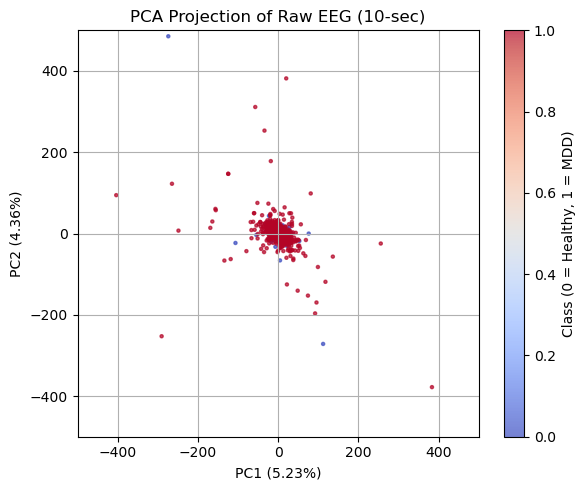

In [162]:
scaler_raw = StandardScaler()
X_raw_10_flat = X_raw_10.reshape(X_raw_10.shape[0], -1)
X_raw_10_scaled = scaler_raw.fit_transform(X_raw_10_flat)

# PCA
pca_raw = PCA(n_components=2, random_state=RANDOM_STATE)
X_raw_10_pca = pca_raw.fit_transform(X_raw_10_scaled)

# plot PCA
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_raw_10_pca[:,0],
    X_raw_10_pca[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_raw.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_raw.explained_variance_ratio_[1]:.2%})")
plt.xlim(-500, 500)
plt.ylim(-500, 500)
plt.title("PCA Projection of Raw EEG (10-sec)")

cbar = plt.colorbar(scatter)
cbar.set_label("Class (0 = Healthy, 1 = MDD)")


plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation 

The PCA projection of raw EEG signals explains less than 10% of the total variance in the first two components and shows substantial overlap between MDD and Healthy samples. This indicates that the dominant variance in raw EEG data is not aligned with class differences, and that flattening the signal combined with linear dimensionality reduction fails to capture discriminative structure. The presence of large outliers further suggests that noise and non-informative variance dominate the representation, compressing the majority of samples into a small region of the space. These findings explain the poor performance of the Raw + PCA + SVM model and highlight the importance of preserving temporal structure or using nonlinear representations for EEG classification. 

In [163]:
umap_raw_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

X_raw_umap = umap_raw_model.fit_transform(X_raw_10_pca)

plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_raw_umap[:,0],
    X_raw_umap[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

plt.title("UMAP projection of the PCA-Reduced Raw EEG (10-sec)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Class (0 = Healthy, 1 = MDD)")

plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

The UMAP projection of PCA-reduced raw EEG reveals strong nonlinear structure in the data, forming  multiple distinct clusters. However, these clusters do not correspond to diagnostic labels, as MDD and healthy samples are intermixed throughout the embedding.

This indicates that while raw EEG signals contain complex structure, the dominant patterns captured after flattening and PCA are not aligned with disease-related differences. As a result, these representations are not directly useful for classification without models capable of learning task-relevant features. 

This explains the poor performance of the Raw + PCA + SVM model, as important temporal and spatial information is lost during preprocessing, and the remaining structure does not correspond to class boundaries. 

Raw EGG contains structure, but it is not easily separable using simple probablistic clustering. Nonlinear embedding (UMAP) reveals this structure, and deep learning models (CNN) can succesfully exploit it. 

## 10. RAW EEG for Deep Learning 

CNN-style can learn local temporal patterns directly from raw EEG windows. Before training , each segment is z-scored channel-wise to reduce baseline and amplitude differences across recordings. 

In [ ]:
print(X_raw_10.shape)
print(y_raw_10.shape)
print(np.unique(y_raw_10))

(7339, 20, 2560)
(7339,)
[0 1]


In [ ]:
def zscore_segments(X):
    """
    Z-score each segment/channel across time.

    Input:
        X shape:(n_samples, n_channels, n_timepoints)

    Output: 
        Same shape, float32
    """

    X = X.astype(np.float32, copy=True)  

    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    std[std == 0] = 1.0
    
    X = (X - mean) / std

    return X

# Normalize
X_raw_10_z = zscore_segments(X_raw_10)
print("Z-scored shape:", X_raw_10_z.shape)

# CNN input format: (samples, timepoints, channels)
X_cnn = np.transpose(X_raw_10_z, (0,2,1))
print("CNN input shape:", X_cnn.shape)

Z-scored shape: (7339, 20, 2560)
CNN input shape: (7339, 2560, 20)


Z-scoring ensures that each EEG segment is normalized independently, preventing differences in absolute signal amplitude from dominating model learning and allowing neural networks to focus on relative temporal patterns. 

In [ ]:
from tensorflow.keras.layers import BatchNormalization

def build_cnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(32, kernel_size=7, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),

        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')

    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=["accuracy"]
    )

    return model

In [ ]:
# GroupKFold evaluation 

def evaluate_cnn_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=n_splits)

    acc_scores = []
    f1_scores = []
    auc_scores = []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        print(f"\n===Fold {fold} ===")

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_STATE + fold)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_cnn_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, 
            y_train, 
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)
        histories.append(history.history)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Fold {fold} Accuracy: {acc:.4f}")
        print(f"Fold {fold} F1: {f1:.4f}")
        print(f"Fold {fold} ROC-AUC: {auc:.4f}")

    summary = {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
}

    return summary 

### Run CNN 

In [ ]:
cnn_results = run_or_load_model(
    model_key = "baseline_cnn_10sec",
    model_name= "Raw + Baseline CNN",
    train_function=evaluate_cnn_groupkfold,
    X=X_cnn,
    y=y_raw_10,
    groups=groups_raw_10,
    window_sec=10,
    notes="Baseline Conv1D model on z-scored raw EEG 10-sec segments",
    n_splits=5,
    epochs=10,
    batch_size=32
)

summarize_cache_result(cnn_results,"Baseline CNN")

Training Raw + Baseline CNN because cache was missing or RUN_DEEP_MODELS=True.

===Fold 1 ===

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.7839 - loss: 0.4424 - val_accuracy: 0.8504 - val_loss: 0.6474
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 29s 195ms/step - accuracy: 0.8755 - loss: 0.2910 - val_accuracy: 0.8343 - val_loss: 0.6717
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 222ms/step - accuracy: 0.9171 - loss: 0.2101 - val_accuracy: 0.8495 - val_loss: 0.6752
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 206ms/step - accuracy: 0.9423 - loss: 0.1614 - val_accuracy: 0.8478 - val_loss: 0.7451
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Fold 1 Accuracy: 0.8934
Fold 1 F1: 0.9027
Fold 1 ROC-AUC: 0.9790

===Fold 2 ===
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 200ms/step - accuracy: 0.8148 - loss: 0.4089 - val_accuracy: 0.7705 - val_loss: 0.7712
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 31s 209ms/step - accuracy: 0.9006 - loss: 0.2646 - val_accuracy: 0.8276 - val_loss: 0.6347

,fold,accuracy,f1,roc_auc
0,1,0.893408,0.902689,0.978979
1,2,0.879648,0.878249,0.956370
2,3,0.713900,0.750881,0.836062
3,4,0.884615,0.898996,0.966993
4,5,0.804762,0.801659,0.863078


In [ ]:
welch_svm_10 = window_results_df[
    (window_results_df["window_sec"] == 10.0) &
    (window_results_df["model_name"] == "SVM RBF")
].iloc[0]

In [ ]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"]
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": raw_pca_df.loc[0, "accuracy"],
        "f1": raw_pca_df.loc[0, "f1"],
        "roc_auc": raw_pca_df.loc[0, "roc_auc"]
    },
    {
        "method": "Raw + Baseline CNN (10 sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    }
])

comparison_df = comparison_df.sort_values(by="roc_auc", ascending=False)

comparison_df

,method,accuracy,f1,roc_auc
2,Raw + Baseline CNN (10 sec),0.835267,0.846495,0.920297
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440


CNN on raw EEG outperfoms both classical and raw features and Welch-based features.

- CNN extracts structure, achieved ~0.92 ROC-AUC (highest overall)
- outperfomed both Welch + SVM and Raw + PCA + SVM
- indicates raw EEG contains rich temporal information
- deep learning captures structure missed by classical models
- some variability across folds
- Fold 1: 0.99 ROC-AUC
- Fold 3: 0.82 ROC-AUC
- Large spread 

possible reasons for variability: 
- subject variability
- class imbalance per fold
- CNN sensitivity to training split 


Interpretation:

The comparison across feature-based and raw signal approaches highlights clear differences in representational effectiveness. The Welch + SVM model provides a strong baseline, achieving high accuracy and ROC-AUC by leveraging domain-specifi spectral features. In constrast, the RAW + PCA + SVM model performs substantially worse, indicating that flattening raw EEG signals and applying dimensionality reduction fails to preserve meaningful structure for classification. 

The baseline CNN applied diectly to raw EEG signals achieves the best overall performance, surpassing both traditional approaches. This suggests that while raw EEG contains discriminative information, it is embedded in a complex, nonlinear structure that cannot be captued by linear methods such as PCA. Instead, convolutional neural networks are able to learn relevant spatial and temporal patterns directly from the data, resulting in improved classification performance. 


### LSTM

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        LSTM(64, return_sequences=False, recurrent_dropout=0.2),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model 

In [ ]:
def evaluate_lstm_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=n_splits)

    acc_scores = []
    f1_scores = []
    auc_scores = []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        print(f"\n===Fold {fold} ===")

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_STATE + fold)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_lstm_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, 
            y_train, 
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)
        histories.append(history.history)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Fold {fold} accuracy: {acc:.4f}")
        print(f"Fold {fold} F1: {f1:.4f}")
        print(f"Fold {fold} ROC-AUC: {auc:.4f}")

    summary = {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories 
    }

    return summary 

In [ ]:
lstm_results = run_or_load_model(
    model_key="lstm_10sec",
    model_name="Raw + LSTM",
    train_function=evaluate_lstm_groupkfold,
    X=X_cnn,
    y=y_raw_10,
    groups=groups_raw_10,
    window_sec=10,
    notes="LSTM model on z-scored raw EEG 10-sec segments",
    n_splits=5,
    epochs=10,
    batch_size=32
)

summarize_cache_result(lstm_results, "LSTM")

Training Raw + LSTM because cache was missing or RUN_DEEP_MODELS=True.

===Fold 1 ===
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.5017 - loss: 0.6984 - val_accuracy: 0.6027 - val_loss: 0.6798
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6097 - loss: 0.6529 - val_accuracy: 0.4877 - val_loss: 0.6999
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6455 - loss: 0.6193 - val_accuracy: 0.5309 - val_loss: 0.6959
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.6833 - loss: 0.5800 - val_accuracy: 0.6762 - val_loss: 0.6670
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.7285 - loss: 0.5340 - val_accuracy: 0.8656 - val_loss: 0.5893
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.7759 - loss: 0.4907 - val_accuracy: 0.8715 - val_loss: 0.5783
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.7901 - loss: 0.4636 - val_accuracy: 0.8740 - val_loss: 0.5882
Epoch 8/10


,fold,accuracy,f1,roc_auc
0,1,0.822581,0.846574,0.849946
1,2,0.812035,0.826683,0.864898
2,3,0.651822,0.657825,0.817831
3,4,0.580297,0.571034,0.666370
4,5,0.697959,0.724907,0.758847


## LSTM Window-size Sensitivity Experiment

The original LSTM result uses 10-sec raw EEG windows. The cells below extend the same cached LSTM workflow to additional temporal window lengths so the final report can compare whether longer temporal context improves performance. 

Default window sizes tested here: 10, and 15 seconds. The 10-second result reuses the exisiting lstm_10sec cache when available. The 15- and 20-second datasets are built and cached only when needed. 


In [ ]:

def prepare_lstm_input_for_window(window_sec):
    """
    Load/build raw EEG windows, z-score each segment channel-wise, and transpose for Keras LSTM.
    
    Output shape:
    (samples, timepoints, channels)
    """

    # Reuse existing 10-sec variables if they are already in memory.
    if int(window_sec) == 10 and all(
        name in globals()
        for name in ["X_cnn", "y_raw_10", "groups_raw_10", "raw_seg_df_10"]
    ):
        print("Using exisiting 10-sec LSTM input from memory...")
        return X_cnn, y_raw_10, groups_raw_10, raw_seg_df_10
    
    X_raw, y_raw, groups_raw, raw_seg_df = get_or_build_raw_segmented_data(
        metadata_df,
        COMMON_CHANNELS,
        window_sec=(window_sec)
    )

    X_raw_z = zscore_segments(X_raw)
    X_lstm = np.transpose(X_raw_z, (0,2,1))

    print(f"{window_sec}-sec LSTM input shape:", X_lstm.shape)
    print(f"{window_sec}-sec number of segments:", len(X_lstm))
    
    return X_lstm, y_raw, groups_raw, raw_seg_df 



In [ ]:
import gc

# Run/load cached LSTM results across multiple window sizes.
LSTM_WINDOW_SIZES = [10, 15]

lstm_window_results = {}

for window_sec in LSTM_WINDOW_SIZES:
    X_lstm_window, y_lstm_window, groups_lstm_window, raw_seg_df_window = prepare_lstm_input_for_window(window_sec)

    model_key = f"lstm_{int(window_sec)}sec"

    lstm_window_results[window_sec] = run_or_load_model(
        model_key=model_key,
        model_name="Raw + LSTM",
        train_function=evaluate_lstm_groupkfold,
        X=X_lstm_window,
        y=y_lstm_window,
        groups=groups_lstm_window,
        window_sec=window_sec,
        notes=f"LSTM model on z-scored raw EEG {window_sec}-sec segments",
        n_splits=N_SPLITS,
        epochs=10,
        batch_size=32
    )

    # Free memory before next window size
    del X_lstm_window, y_lstm_window, groups_lstm_window, raw_seg_df_window
    gc.collect()

print("Finished LSTM window-size cache check.")

Using exisiting 10-sec CNN/LSTM input from memory...
Loaded cached results for lstm_10sec
Building raw segmented data for 15s...
15-sec LSTM input shape: (4872, 3840, 20)
15-sec number of segments: 4872
Training Raw + LSTM because cache was missing or RUN_DEEP_MODELS=True.

===Fold 1 ===
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - accuracy: 0.4961 - loss: 0.7012 - val_accuracy: 0.6452 - val_loss: 0.6682
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.5604 - loss: 0.6751 - val_accuracy: 0.5951 - val_loss: 0.6738
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.6353 - loss: 0.6441 - val_accuracy: 0.5630 - val_loss: 0.6787
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.6449 - loss: 0.6253 - val_accuracy: 0.5681 - val_loss: 0.6729
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 613ms/step
Fold 1 accuracy: 0.6222
Fold 1 F1: 0.6271
Fold 1 ROC-AUC: 0.6765

===Fold 2 ===
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.5842 - loss: 0.6

In [ ]:
def build_deep_model_comparison(results_map, output_name="deep_model_comparison.csv"):
    """
    Combine cache deep=learning summary files into one comparison table.

    Parameters
    ----------
    results_map : dict
        Dictionary mapping model_key -> display method name. 
    ouput_name : str
        Output CSV filename saved under results/tables/.
    """

    rows = []

    for model_key, display_name in results_map.items():
        summary_path = CACHE_DIR / f"{model_key}_summary.csv"

        if summary_path.exists():
            row = pd.read_csv(summary_path).iloc[0].to_dict()
            row["method"] = display_name
            rows.append(row)
        else:
            print(f"Missing cache for {display_name}: {summary_path}")

    comparison = pd.DataFrame(rows)

    if not comparison.empty:
        comparison = comparison.rename(columns={"roc-auc":"roc_auc", "n-folds":"n_folds"})

        if "n_folds" not in comparison.columns:
            comparison["n_folds"] = N_SPLITS
        else:
            comparison["n_folds"] = comparison["n_folds"].fillna(N_SPLITS)

        cols = [
            "method",
            "model_name",
            "window_sec",
            "accuracy",
            "f1",
            "roc_auc",
            "n_folds",
            "notes"
        ]
        
        comparison = comparison[[c for c in cols if c in comparison.columns]]

        output_path = TABLES_DIR / output_name
        output_path.parent.mkdir(parents=True, exist_ok=True)
        comparison.to_csv(output_path, index=False)

        print(f"Saved comparison table to: {output_path}")

    return comparison


In [ ]:
# Build a clean LSTM-only window-size comparison table. 
lstm_window_results_map = {
    f"lstm_{int(window_sec)}sec": f"Raw + LSTM ({int(window_sec)} sec)"
    for window_sec in LSTM_WINDOW_SIZES
}

lstm_window_comparison_df = build_deep_model_comparison(
    lstm_window_results_map,
    output_name="lstm_window_size_comparison.csv"
)

lstm_window_comparison_df

Saved comparison table to: d:\eeg-mdd-classification\results\tables\lstm_window_size_comparison.csv


,method,model_name,window_sec,accuracy,f1,roc_auc,n_folds,notes
0,Raw + LSTM (10 sec),Raw + LSTM,10,0.712939,0.725405,0.791578,5,LSTM model on z-scored raw EEG 10-sec segments
1,Raw + LSTM (15 sec),Raw + LSTM,15,0.585644,0.585211,0.698707,5,LSTM model on z-scored raw EEG 15-sec segments


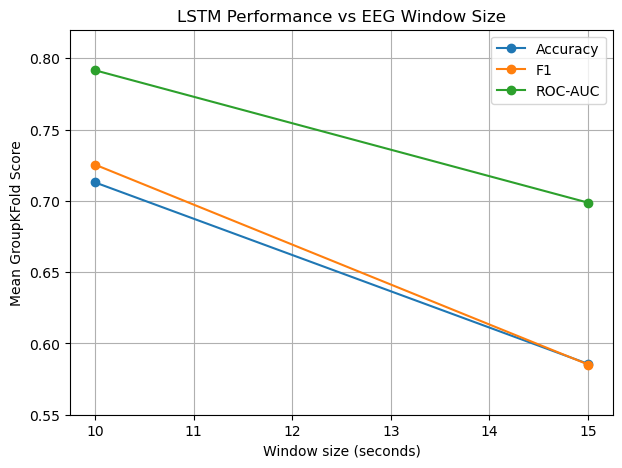

In [ ]:
# Visualizatiion: LSTM performance vs window size.
if not lstm_window_comparison_df.empty:
    plot_df = lstm_window_comparison_df.sort_values("window_sec")

    plt.figure(figsize=(7,5))
    plt.plot(plot_df["window_sec"], plot_df["accuracy"], marker="o", label="Accuracy")
    plt.plot(plot_df["window_sec"], plot_df["f1"], marker="o", label="F1")
    plt.plot(plot_df["window_sec"], plot_df["roc_auc"], marker="o", label="ROC-AUC")
    plt.ylim(0.55, 0.82)
    plt.xlabel("Window size (seconds)")
    plt.ylabel("Mean GroupKFold Score")
    plt.title("LSTM Performance vs EEG Window Size")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No LSTM window comparison results found yet.")

## Interpretation: 

Model performance decreased substantially as EEG window size increased from 10 to 15 seconds. The 10-sec segmentation produced higher accuracy, F1-score, and ROC-AUC across all evaluation metrics. These results suggest that shorter EEG windows preserved more informative temporal patterns while also increasing the number of training samples available to the LSTM model. 

This contrasts with the Welch-based models, where longer windows improved performance due to enhanced frequency resolution. For the LSTM, the additional temporal context provided by longer windows does not appear to introduce new discriminative information, and may instead introduce noise/redudancy. 

These results suggest that, for sequence-based models, moderate window sizes (e.g., 10 seconds) are sufficient to capture relevant temporal patterns in the EEG signal. 

In [ ]:
comparison_df = pd.DataFrame([
     {
        "method": "Welch + SVM (10 sec)",
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"]
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": raw_pca_df.loc[0, "accuracy"],
        "f1": raw_pca_df.loc[0, "f1"],
        "roc_auc": raw_pca_df.loc[0, "roc_auc"]
    },
    {
        "method": "Raw + CNN (10 sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
         "method": "Raw + LSTM (10 sec)",
        "accuracy": lstm_results["accuracy"],
        "f1": lstm_results["f1"],
        "roc_auc": lstm_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (10 sec),0.835267,0.846495,0.920297
3,Raw + LSTM (10 sec),0.712939,0.725405,0.791578


## CNN + LSTM

In [ ]:
def build_cnn_lstm_model(input_shape):
    model = Sequential([

        Input(shape=input_shape),

        # CNN feature extractor
        Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=128, kernel_size=3, activation='relu',padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Temporal modeling
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # Classification head
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def evaluate_cnn_lstm_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        groups_train_full = groups[train_idx]

        # Group-aware validation split
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42 + fold
        )

        train_sub_idx, val_sub_idx = next(
            gss.split(X_train_full, y_train_full, groups_train_full)
        )

        X_train = X_train_full[train_sub_idx]
        y_train = y_train_full[train_sub_idx]

        X_val = X_train_full[val_sub_idx]
        y_val = y_train_full[val_sub_idx]

        model = build_cnn_lstm_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }


In [ ]:
cnn_lstm_results = run_or_load_model(
    model_key="raw_cnn_lstm_10sec",
    model_name="Raw + CNN-LSTM (10s)",
    train_function=evaluate_cnn_lstm_groupkfold,
    X=X_cnn,
    y=y_raw_10, 
    groups=groups_raw_10,
    window_sec=10,
    notes="CNN feature extractor followed by LSTM on raw EEG 10-sec segments",
    n_splits=5,
    epochs=10,
    batch_size=32
)

summarize_cache_result(cnn_lstm_results, "CNN-LSTM")

Training Raw + CNN-LSTM (10s) because cache was missing or RUN_DEEP_MODELS=True.

=== Fold 1 ===
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 107s 558ms/step - accuracy: 0.7523 - loss: 0.5081 - val_accuracy: 0.8102 - val_loss: 0.6271
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 71s 488ms/step - accuracy: 0.8217 - loss: 0.4173 - val_accuracy: 0.7180 - val_loss: 0.7334
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 73s 502ms/step - accuracy: 0.8399 - loss: 0.4054 - val_accuracy: 0.6739 - val_loss: 0.7013
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 72s 494ms/step - accuracy: 0.8222 - loss: 0.4099 - val_accuracy: 0.7831 - val_loss: 0.7163
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step
Acc: 0.864 | F1: 0.879 | AUC: 0.913

=== Fold 2 ===
Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 72s 485ms/step - accuracy: 0.7898 - loss: 0.4663 - val_accuracy: 0.7216 - val_loss: 0.8351
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 72s 504ms/step - accuracy: 0.8223 - loss: 0.4378 - val_accuracy: 0.7455 - val_loss: 0.7623
Epoch 3/10
142/142 ━━━━

,fold,accuracy,f1,roc_auc
0,1,0.863955,0.879052,0.912824
1,2,0.808654,0.829209,0.849513
2,3,0.705803,0.758850,0.726342
3,4,0.827935,0.864865,0.919214
4,5,0.731973,0.748082,0.811660


In [ ]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch Features + SVM",
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"]
    },
    {
        "method": "PCA features + SVM",
        "accuracy": raw_pca_df.loc[0, "accuracy"],
        "f1": raw_pca_df.loc[0, "f1"],
        "roc_auc": raw_pca_df.loc[0, "roc_auc"]
    },
  {
        "method": "Raw EEG + CNN",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
         "method": "Raw EEG + LSTM",
        "accuracy": lstm_results["accuracy"],
        "f1": lstm_results["f1"],
        "roc_auc": lstm_results["roc_auc"]
    },
    {
        "method": "Raw EEG + CNN-LSTM",
        "accuracy": cnn_lstm_results["accuracy"],
        "f1": cnn_lstm_results["f1"],
        "roc_auc": cnn_lstm_results["roc_auc"]
    }
])


comparison_df

,method,accuracy,f1,roc_auc
0,Welch Features + SVM,0.827231,0.844465,0.908115
1,PCA features + SVM,0.702891,0.778403,0.807440
2,Raw EEG + CNN,0.835267,0.846495,0.920297
3,Raw EEG + LSTM,0.712939,0.725405,0.791578
4,Raw EEG + CNN-LSTM,0.787664,0.816012,0.843911


## Interpretation: 

The CNN model achieved the best-overall performance, outperforming both the standalone LSTM and the combined CNN-LSTM architecture. While the CNN effectively captures local temporal and spatial patterns in the EEG signal, the addition of an LSTM layer did not improve performance and instead resulted in a noticeable decrease in accuracy and ROC-AUC. 

This suggests that the discriminative information in the EEG data is primarily contained in local patterns that can be effectively extracted by convolutional filters, and that modeling longer temporal dependencies does not provide additional benefit. The CNN-LSTM model likely introduces unnecessary complexity, which may lead to overfitting or difficulty in optimization without improving representation quality. 

Overall, these results indicate that convolutional architectures are sufficient for this task, and that sequence-based extensions such as LSTMs do not offer a performance advantage for the given data and window size. 

## CNN Limitation 1: Deeper CNN

In [ ]:
def build_cnn_deeper(input_shape):

    model = Sequential([
        
        # Input 
        Input(shape=input_shape),

        # Block 1
        Conv1D(
            filters=32,
            kernel_size=7,
            padding='same'
        ),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Block 2 
        Conv1D(
            filters=64,
            kernel_size=5,
            padding='same'
        ),
        MaxPooling1D(pool_size=2),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        # Block 3
        Conv1D(
            filters=128,
            kernel_size=5,
            padding='same'
        ),
        MaxPooling1D(pool_size=2),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        # ===== (NEW DEPTH) =====
        Conv1D(
            filters=256,
            kernel_size=3,
            padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        # Global feature aggregation
        GlobalAveragePooling1D(),

        # Classifier head
        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def run_cnn_deeper_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        groups_train_full = groups[train_idx]

        # Group-aware validation split
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42 + fold
        )

        train_sub_idx, val_sub_idx = next(
            gss.split(X_train_full, y_train_full, groups_train_full)
        )

        X_train = X_train_full[train_sub_idx]
        y_train = y_train_full[train_sub_idx]

        X_val = X_train_full[val_sub_idx]
        y_val = y_train_full[val_sub_idx]
        
        model = build_cnn_deeper(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }

In [ ]:
cnn_deeper_results = run_or_load_model(
    model_key= "raw deep_cnn_10sec",
    model_name="Raw + Deep CNN (10s)",
    train_function=run_cnn_deeper_groupkfold,
    X=X_cnn,
    y=y_raw_10,
    groups=groups_raw_10,
    window_sec=10,
    notes="Deeper Conv1D model on z-scored raw EEG 10-sec segments",
    n_splits=5,
    epochs=10,
    batch_size=32
)

summarize_cache_result(cnn_deeper_results, "Deep CNN")

Training Raw + Deep CNN (10s) because cache was missing or RUN_DEEP_MODELS=True.

=== Fold 1 ===
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 75s 432ms/step - accuracy: 0.9143 - loss: 0.2091 - val_accuracy: 0.7885 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 57s 394ms/step - accuracy: 0.9699 - loss: 0.0852 - val_accuracy: 0.7893 - val_loss: 0.7769 - learning_rate: 0.0010
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 63s 437ms/step - accuracy: 0.9805 - loss: 0.0580 - val_accuracy: 0.7715 - val_loss: 1.6525 - learning_rate: 0.0010
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9759 - loss: 0.0656
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
145/145 ━━━━━━━━━━━━━━━━━━━━ 61s 422ms/step - accuracy: 0.9794 - loss: 0.0600 - val_accuracy: 0.7351 - val_loss: 1.6567 - learning_rate: 0.0010
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 67s 464ms/step - accuracy: 0.9924 - loss: 0.0250 - val_accuracy: 0.7645 - val_loss: 1.5592

,fold,accuracy,f1,roc_auc
0,1,0.973352,0.973757,0.998489
1,2,0.682218,0.747040,0.919023
2,3,0.667341,0.632911,0.825790
3,4,0.658570,0.599684,0.956580
4,5,0.671429,0.744580,0.932925


In [ ]:
comparison_df = pd.DataFrame([
      {
        "method": "Welch Features + SVM",
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"]
    },
    {
        "method": "PCA features + SVM",
        "accuracy": raw_pca_df.loc[0, "accuracy"],
        "f1": raw_pca_df.loc[0, "f1"],
        "roc_auc": raw_pca_df.loc[0, "roc_auc"]
    },
  {
        "method": "Raw EEG + CNN",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
         "method": "Raw EEG + LSTM",
        "accuracy": lstm_results["accuracy"],
        "f1": lstm_results["f1"],
        "roc_auc": lstm_results["roc_auc"]
    },
    {
        "method": "Raw EEG + CNN-LSTM",
        "accuracy": cnn_lstm_results["accuracy"],
        "f1": cnn_lstm_results["f1"],
        "roc_auc": cnn_lstm_results["roc_auc"]
    },
    {
        "method": "Raw EEG + Deep CNN",
        "accuracy": cnn_deeper_results["accuracy"],
        "f1": cnn_deeper_results["f1"],
        "roc_auc": cnn_deeper_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch Features + SVM,0.827231,0.844465,0.908115
1,PCA features + SVM,0.702891,0.778403,0.807440
2,Raw EEG + CNN,0.835267,0.846495,0.920297
3,Raw EEG + LSTM,0.712939,0.725405,0.791578
4,Raw EEG + CNN-LSTM,0.787664,0.816012,0.843911
5,Raw EEG + Deep CNN,0.730582,0.739594,0.926561


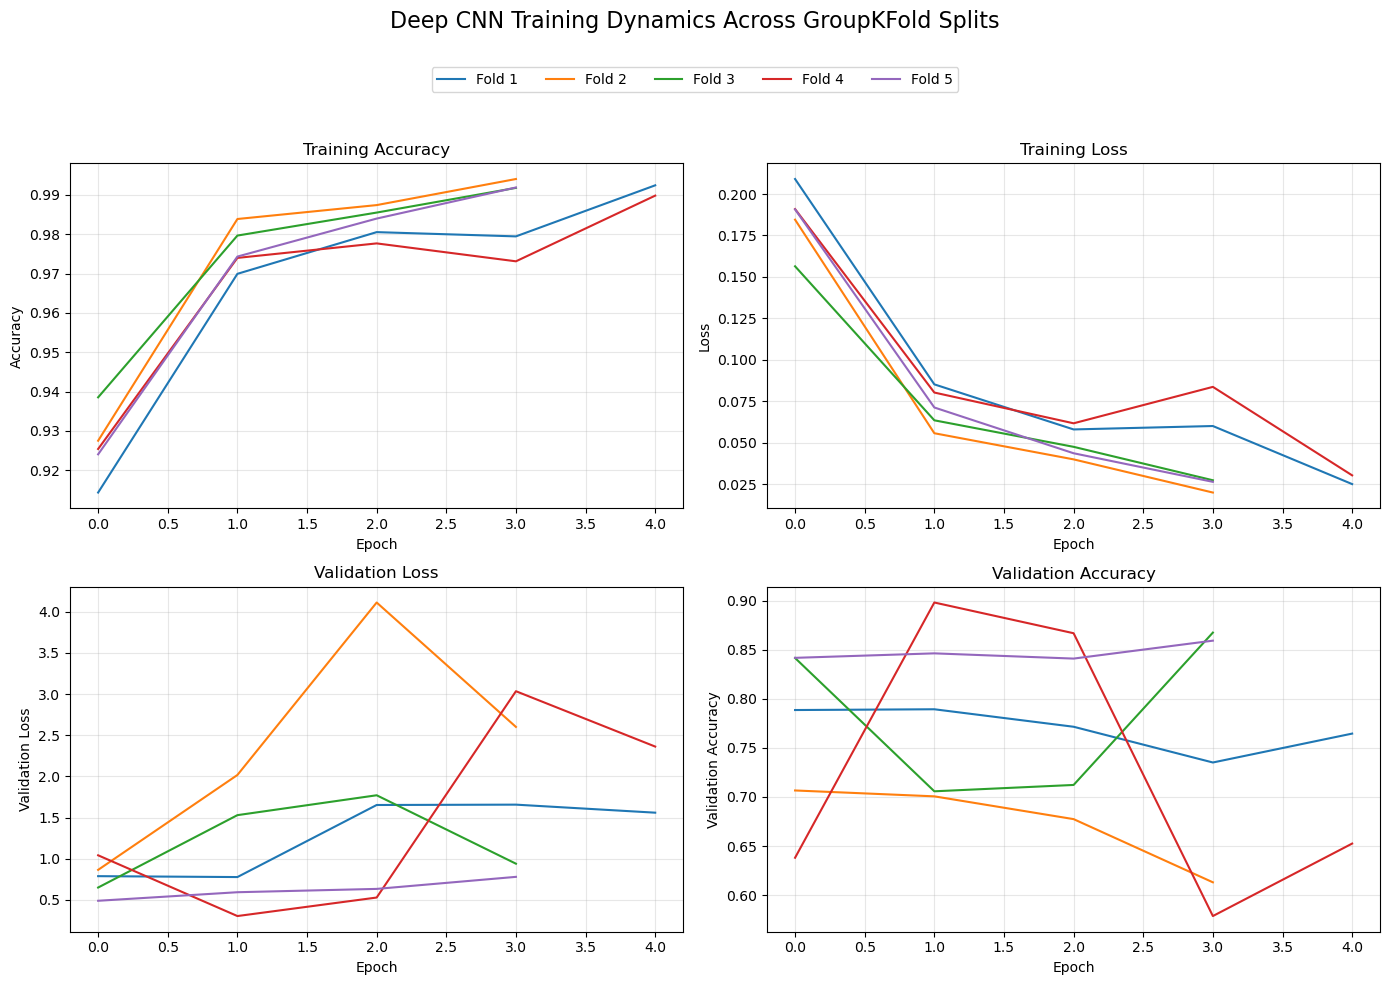

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Training Accuracy =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[0, 0].plot(hist["accuracy"], label=f"Fold {i+1}")

axes[0, 0].set_title("Training Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].grid(alpha=0.3)

# ===== 2. Training Loss =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[0, 1].plot(hist["loss"], label=f"Fold {i+1}")

axes[0, 1].set_title("Training Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(alpha=0.3)

# ===== 3. Validation Loss =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[1, 0].plot(hist["val_loss"], label=f"Fold {i+1}")

axes[1, 0].set_title("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Validation Loss")
axes[1, 0].grid(alpha=0.3)

# ===== 4. Validation Accuracy =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[1, 1].plot(hist["val_accuracy"], label=f"Fold {i+1}")

axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Validation Accuracy")
axes[1, 1].grid(alpha=0.3)

# Overall title
plt.suptitle(
    "Deep CNN Training Dynamics Across GroupKFold Splits",
    fontsize=16,
    y=0.98
)

# Shared legend 
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels, 
    loc="upper center",
    ncol=5, 
    bbox_to_anchor=(0.5, 0.93)
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

The Deep CNN demonstrates strong learning capacity across all folds, with training accuracy consistently reaching 0.96–0.98 and rapidly decreasing training loss, indicating effective feature extraction from EEG signals. However, validation performance exhibits substantial instability across subject-wise splits. While some folds achieve strong generalization performance (e.g., Fold 4 with validation accuracy ~0.94 and relatively low validation loss), other folds show degraded performance with significantly higher validation loss (up to ~4.5) and reduced accuracy.

This divergence between training and validation behavior suggests that although the model is highly expressive, it is sensitive to inter-subject variability inherent in EEG data. The inconsistent validation loss trends and fluctuating validation accuracy across folds indicate that improvements in training performance do not always translate to robust generalization. As a result, the Deep CNN provides high peak performance but lacks consistent stability across all subject partitions, highlighting a trade-off between model complexity and robustness in EEG classification tasks.

High validation loss and high validation accuracy variabilities

## CNN Limitation 2: Multi-scale CNN

In [ ]:
def build_multiscale_cnn(input_shape):

    inputs = Input(shape=input_shape)

    # ===== Branch 1: small scale =====
    x1 = Conv1D(32, kernel_size=3, padding='same')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Activation('relu')(x1)
    x1 = MaxPooling1D(2)(x1)

    # ===== Branch 2: medium scale =====
    x2 = Conv1D(32, kernel_size=5, padding='same')(inputs)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x2 = MaxPooling1D(2)(x2)

    # ===== Branch 3: large scale =====
    x3 = Conv1D(32, kernel_size=9, padding='same')(inputs)
    x3 = BatchNormalization()(x3)
    x3 = Activation('relu')(x3)
    x3 = MaxPooling1D(2)(x3)

    # ===== Merge =====
    merged = Concatenate()([x1, x2, x3])
    merged = Dropout(0.2)(merged)

    # Further feature extraction
    x = Conv1D(64, kernel_size=3, padding='same')(merged)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.3)(x)

    # Global feature aggregation
    x = GlobalAveragePooling1D()(x)

    # Classifier
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def run_multiscale_cnn_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        groups_train_full = groups[train_idx]

        # Group-aware validation split
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42 + fold
        )

        train_sub_idx, val_sub_idx = next(
            gss.split(X_train_full, y_train_full, groups_train_full)
        )

        X_train = X_train_full[train_sub_idx]
        y_train = y_train_full[train_sub_idx]

        X_val = X_train_full[val_sub_idx]
        y_val = y_train_full[val_sub_idx]
       
        model = build_multiscale_cnn(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }

In [ ]:
multiscale_results = run_or_load_model(
    model_key="multiscale_cnn_10sec",
    model_name= "Raw EEG + Multi-Scale CNN (10s)",
    train_function=run_multiscale_cnn_groupkfold,
    X=X_cnn,
    y=y_raw_10,
    groups=groups_raw_10,
    window_sec=10,
    notes="Multi-branch Conv1D kernels on z-scored raw EEG 10-second segments",
    n_splits=5,
    epochs=10,
    batch_size=32
)

summarize_cache_result(multiscale_results, "Multi-Scale CNN")

Training Raw EEG + Multi-Scale CNN (10s) because cache was missing or RUN_DEEP_MODELS=True.

=== Fold 1 ===
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 52s 308ms/step - accuracy: 0.8771 - loss: 0.2945 - val_accuracy: 0.7831 - val_loss: 0.9025 - learning_rate: 0.0010
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 44s 301ms/step - accuracy: 0.9574 - loss: 0.1212 - val_accuracy: 0.6933 - val_loss: 1.1154 - learning_rate: 0.0010
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9724 - loss: 0.0797
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
145/145 ━━━━━━━━━━━━━━━━━━━━ 43s 296ms/step - accuracy: 0.9764 - loss: 0.0695 - val_accuracy: 0.7661 - val_loss: 1.1084 - learning_rate: 0.0010
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - accuracy: 0.9890 - loss: 0.0412 - val_accuracy: 0.7537 - val_loss: 1.0321 - learning_rate: 5.0000e-04
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
Acc: 0.895 | F1: 0.904 | AUC: 0.997

=== Fold 2 ===
Epoch 1/10
142/142 ━━━━

,fold,accuracy,f1,roc_auc
0,1,0.894811,0.903846,0.996656
1,2,0.711968,0.764901,0.914838
2,3,0.771255,0.808149,0.866224
3,4,0.844804,0.879581,0.956296
4,5,0.861905,0.850405,0.855412


In [ ]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"]
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": raw_pca_df.loc[0, "accuracy"],
        "f1": raw_pca_df.loc[0, "f1"],
        "roc_auc": raw_pca_df.loc[0, "roc_auc"]
    },
    {
        "method": "Raw + Baseline CNN (10-sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
        "method": "Raw + LSTM (10-sec)",
        "accuracy": lstm_results["accuracy"],
        "f1": lstm_results["f1"],
        "roc_auc": lstm_results["roc_auc"]
    },
    {
        "method": "Raw + CNN-LSTM (10-sec)",
        "accuracy": cnn_lstm_results["accuracy"],
        "f1": cnn_lstm_results["f1"],
        "roc_auc": cnn_lstm_results["roc_auc"]
    },
    {
        "method": "Raw + Deep CNN",
        "accuracy": cnn_deeper_results["accuracy"],
        "f1": cnn_deeper_results["f1"],
        "roc_auc": cnn_deeper_results["roc_auc"]
    },
    {
        "method": "Raw + Multi-Scale CNN",
        "accuracy": multiscale_results["accuracy"],
        "f1": multiscale_results["f1"],
        "roc_auc": multiscale_results["roc_auc"]
    }
])

# Save the comparison table 
comparison_df.to_csv(RESULTS_DIR / "tables" / "raw_eeg_model_comparison.csv", index=False)
comparison_df 

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + Baseline CNN (10-sec),0.835267,0.846495,0.920297
3,Raw + LSTM (10-sec),0.712939,0.725405,0.791578
4,Raw + CNN-LSTM (10-sec),0.787664,0.816012,0.843911
5,Raw + Deep CNN,0.730582,0.739594,0.926561
6,Raw + Multi-Scale CNN,0.816948,0.841377,0.917885


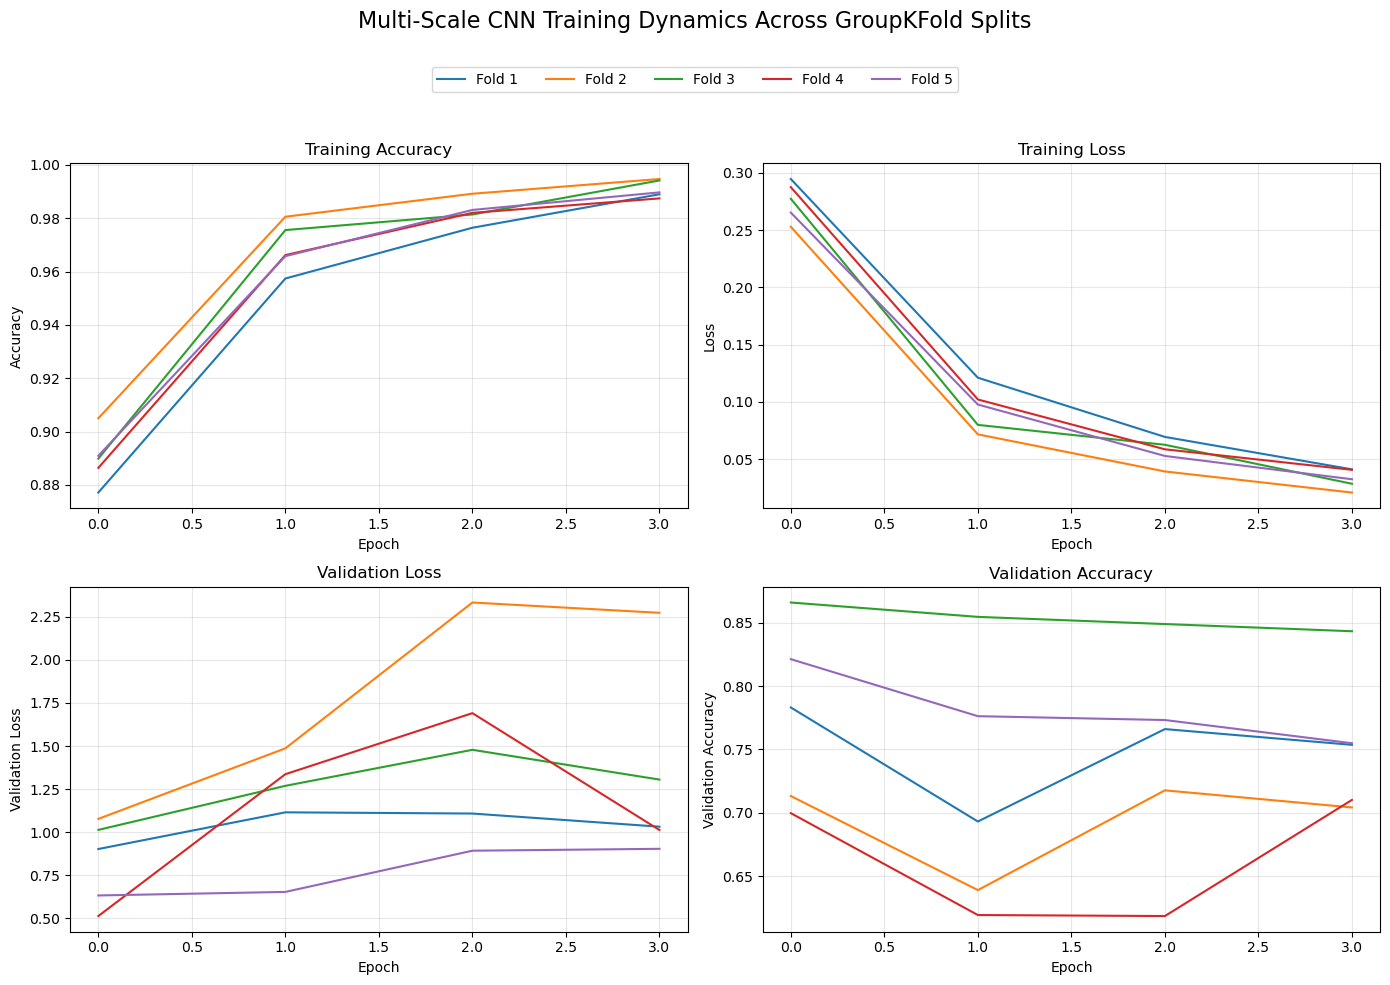

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Training Accuracy =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[0, 0].plot(hist["accuracy"], label=f"Fold {i+1}")

axes[0, 0].set_title("Training Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].grid(alpha=0.3)

# ===== 2. Training Loss =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[0, 1].plot(hist["loss"], label=f"Fold {i+1}")

axes[0, 1].set_title("Training Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(alpha=0.3)

# ===== 3. Validation Loss =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[1, 0].plot(hist["val_loss"], label=f"Fold {i+1}")

axes[1, 0].set_title("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Validation Loss")
axes[1, 0].grid(alpha=0.3)

# ===== 4. Validation Accuracy =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[1, 1].plot(hist["val_accuracy"], label=f"Fold {i+1}")

axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Validation Accuracy")
axes[1, 1].grid(alpha=0.3)

# Overall title
plt.suptitle(
    "Multi-Scale CNN Training Dynamics Across GroupKFold Splits",
    fontsize=16,
    y=0.98
)

# Shared legend 
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc="upper center", 
    ncol=5, 
    bbox_to_anchor=(0.5, 0.93))

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

The Multi-Scale CNN demonstrates strong learning capacity, with training loss consistently decreasing and training accuracy reaching up to 0.97 across folds. However, validation performance exhibits considerable instability, with both validation loss and validation accuracy fluctuating significantly across epochs and folds. In several cases, validation loss increases substantially despite continued improvements in training accuracy, indicating overfitting to training distributions.

Although some folds achieve high validation accuracy, these improvements are not consistently reflected in final test performance, suggesting limited robustness across subject-wise splits. This discrepancy highlights the sensitivity of the model to inter-subject variability in EEG signals. Overall, the Multi-Scale CNN provides strong feature extraction capability but does not achieve stable generalization, indicating that multi-scale convolution alone is insufficient to fully address variability in EEG classification tasks.

## Final Cached Deep-Learning Comparison

This cell collects all cached deep-learning model summaries into one table for the final report.

In [ ]:
deep_results_map = {
    "baseline_cnn_10sec": "Raw EEG + CNN (10s)",
    "lstm_10sec": "Raw EEG + LSTM (10s)",
    "lstm_15sec": "Raw EEG + LSTM (15s)",
    "raw_cnn_lstm_10sec": "Raw EEG + CNN-LSTM (10s)",
    "raw deep_cnn_10sec": "Raw EEG + Deep CNN (10s)",
    "multiscale_cnn_10sec": "Raw EEG + Multi-Scale CNN (10s)",
}

cached_deep_comparison_df = build_deep_model_comparison(deep_results_map)

cached_deep_comparison_df = (
    cached_deep_comparison_df
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
cached_deep_comparison_df

Saved comparison table to: d:\eeg-mdd-classification\results\tables\deep_model_comparison.csv


,method,model_name,window_sec,accuracy,f1,roc_auc,n_folds,notes
0,Raw EEG + Deep CNN (10s),Raw + Deep CNN (10s),10,0.730582,0.739594,0.926561,5,Deeper Conv1D model on z-scored raw EEG 10-sec...
1,Raw EEG + CNN (10s),Raw + Baseline CNN,10,0.835267,0.846495,0.920297,5,Baseline Conv1D model on z-scored raw EEG 10-s...
2,Raw EEG + Multi-Scale CNN (10s),Raw EEG + Multi-Scale CNN (10s),10,0.816948,0.841377,0.917885,5,Multi-branch Conv1D kernels on z-scored raw EE...
3,Raw EEG + CNN-LSTM (10s),Raw + CNN-LSTM (10s),10,0.787664,0.816012,0.843911,5,CNN feature extractor followed by LSTM on raw ...
4,Raw EEG + LSTM (10s),Raw + LSTM,10,0.712939,0.725405,0.791578,5,LSTM model on z-scored raw EEG 10-sec segments
5,Raw EEG + LSTM (15s),Raw + LSTM,15,0.585644,0.585211,0.698707,5,LSTM model on z-scored raw EEG 15-sec segments


## Unified Final Model Comparison Table 

This table combines the classical baselines with the cached deep-learning model summaries. It is the best table to use for the final report because it places Welch features, raw PCA, CNNs, CNN-LSTM, and the LSTM window-size experiment into one place. 

In [ ]:
raw_pca_10 = raw_pca_df.iloc[0]

classical_results_df = pd.DataFrame([
    {
        "method": "Welch Features + SVM",
        "model_name": "Welch + SVM",
        "window_sec": 10,
        "accuracy": welch_svm_10["accuracy"],
        "f1": welch_svm_10["f1"],
        "roc_auc": welch_svm_10["roc_auc"],
        "n_folds": N_SPLITS,
        "notes": "Interpretable Welch relative band-power baseline"
    },
    {
        "method": "PCA Features + SVM",
        "model_name": "PCA + SVM",
        "window_sec": 10,
        "accuracy": raw_pca_10["accuracy"],
        "f1": raw_pca_10["f1"],
        "roc_auc": raw_pca_10["roc_auc"],
        "n_folds": N_SPLITS,
        "notes": "Flattened raw EEG with PCA before SVM"
    }
])

unified_model_comparison_df = pd.concat(
    [classical_results_df, cached_deep_comparison_df],
    ignore_index=True
)

unified_model_comparison_df = unified_model_comparison_df.sort_values(
    by="roc_auc",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

unified_model_comparison_df.to_csv(
    RESULTS_DIR / "tables" / "unified_model_comparison.csv",
    index=False
)

unified_model_comparison_df

,method,model_name,window_sec,accuracy,f1,roc_auc,n_folds,notes
0,Raw EEG + Deep CNN (10s),Raw + Deep CNN (10s),10,0.730582,0.739594,0.926561,5,Deeper Conv1D model on z-scored raw EEG 10-sec...
1,Raw EEG + CNN (10s),Raw + Baseline CNN,10,0.835267,0.846495,0.920297,5,Baseline Conv1D model on z-scored raw EEG 10-s...
2,Raw EEG + Multi-Scale CNN (10s),Raw EEG + Multi-Scale CNN (10s),10,0.816948,0.841377,0.917885,5,Multi-branch Conv1D kernels on z-scored raw EE...
3,Welch Features + SVM,Welch + SVM,10,0.827231,0.844465,0.908115,5,Interpretable Welch relative band-power baseline
4,Raw EEG + CNN-LSTM (10s),Raw + CNN-LSTM (10s),10,0.787664,0.816012,0.843911,5,CNN feature extractor followed by LSTM on raw ...
5,PCA Features + SVM,PCA + SVM,10,0.702891,0.778403,0.807440,5,Flattened raw EEG with PCA before SVM
6,Raw EEG + LSTM (10s),Raw + LSTM,10,0.712939,0.725405,0.791578,5,LSTM model on z-scored raw EEG 10-sec segments
7,Raw EEG + LSTM (15s),Raw + LSTM,15,0.585644,0.585211,0.698707,5,LSTM model on z-scored raw EEG 15-sec segments


In [ ]:
# Fix naming consistency 

unified_model_comparison_df["method"] = unified_model_comparison_df["method"].str.replace("welch", "Welch")

# Standardize model names 
model_map = {
    "Raw + Baseline CNN": "Baseline CNN ",
    "Raw + Deep CNN": "Deep CNN",
    "Raw + Multiscale CNN": "Multi-Scale CNN",
    "Raw + CNN-LSTM": "CNN-LSTM",
    "Raw + LSTM": "LSTM",
    "Welch + SVM": "Welch + SVM",
    "Raw + PCA + SVM": "PCA + SVM"
}

unified_model_comparison_df["model_name"] = unified_model_comparison_df["model_name"].replace(model_map)

# Fill missing fold 
unified_model_comparison_df["n_folds"] = unified_model_comparison_df["n_folds"].fillna(N_SPLITS)

# Sort again 
unified_model_comparison_df = unified_model_comparison_df.sort_values(
    by="roc_auc", ascending=False
).reset_index(drop=True)

unified_model_comparison_df

,method,model_name,window_sec,accuracy,f1,roc_auc,n_folds,notes
0,Raw EEG + Deep CNN (10s),Raw + Deep CNN (10s),10,0.730582,0.739594,0.926561,5,Deeper Conv1D model on z-scored raw EEG 10-sec...
1,Raw EEG + CNN (10s),Baseline CNN,10,0.835267,0.846495,0.920297,5,Baseline Conv1D model on z-scored raw EEG 10-s...
2,Raw EEG + Multi-Scale CNN (10s),Raw EEG + Multi-Scale CNN (10s),10,0.816948,0.841377,0.917885,5,Multi-branch Conv1D kernels on z-scored raw EE...
3,Welch Features + SVM,Welch + SVM,10,0.827231,0.844465,0.908115,5,Interpretable Welch relative band-power baseline
4,Raw EEG + CNN-LSTM (10s),Raw + CNN-LSTM (10s),10,0.787664,0.816012,0.843911,5,CNN feature extractor followed by LSTM on raw ...
5,PCA Features + SVM,PCA + SVM,10,0.702891,0.778403,0.807440,5,Flattened raw EEG with PCA before SVM
6,Raw EEG + LSTM (10s),LSTM,10,0.712939,0.725405,0.791578,5,LSTM model on z-scored raw EEG 10-sec segments
7,Raw EEG + LSTM (15s),LSTM,15,0.585644,0.585211,0.698707,5,LSTM model on z-scored raw EEG 15-sec segments


## Grouped Comparison: Accuracy, F1, ROC-AUC Plot

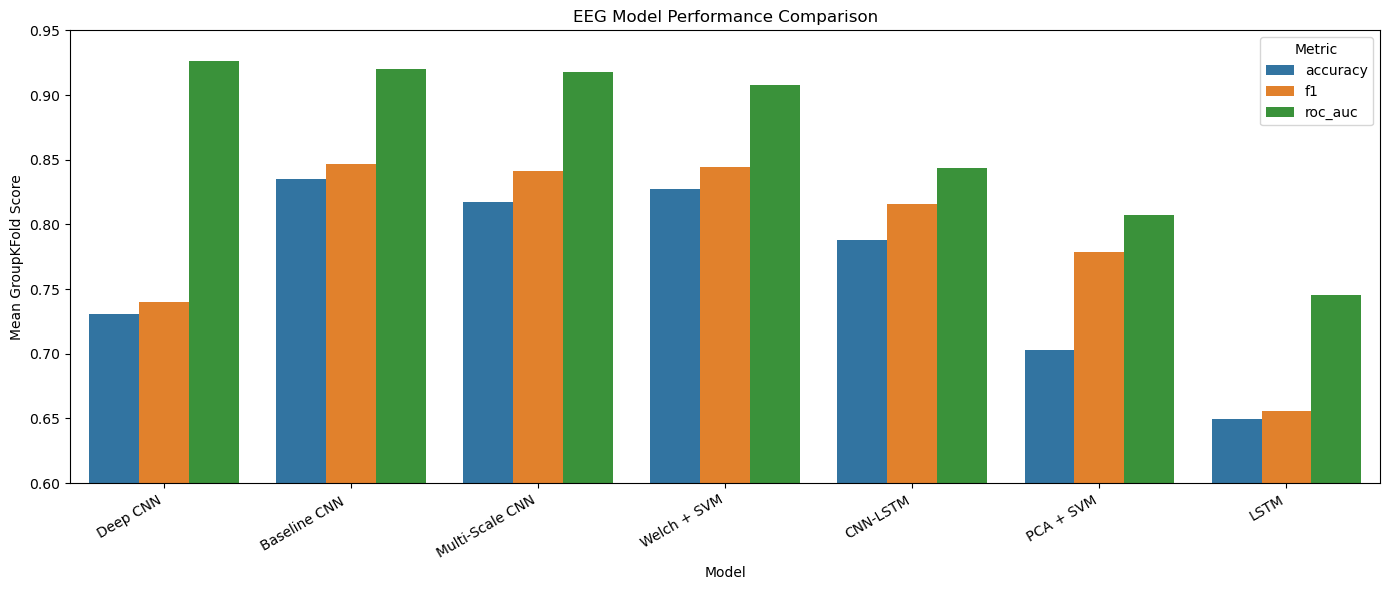

In [ ]:
import seaborn as sns 

plot_df = unified_model_comparison_df.copy()

plot_df["model_name"] = plot_df["model_name"].replace({
    "Raw + Deep CNN (10s)": "Deep CNN",
    "Raw + Baseline CNN": "Baseline CNN",
    "Raw EEG + Multi-Scale CNN (10s)": "Multi-Scale CNN",
    "Raw + CNN-LSTM (10s)": "CNN-LSTM",
    "Raw + LSTM": "LSTM",
    "Welch + SVM": "Welch + SVM",
    "PCA + SVM": "PCA + SVM"
})

metrics_df = plot_df.melt(
    id_vars="model_name",
    value_vars=["accuracy", "f1", "roc_auc"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=metrics_df,
    x="model_name",
    y="Score",
    hue="Metric",
    errorbar=None
)

plt.title("EEG Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean GroupKFold Score")
plt.ylim(0.60, 0.95)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## ROC-AUC ranking plot 

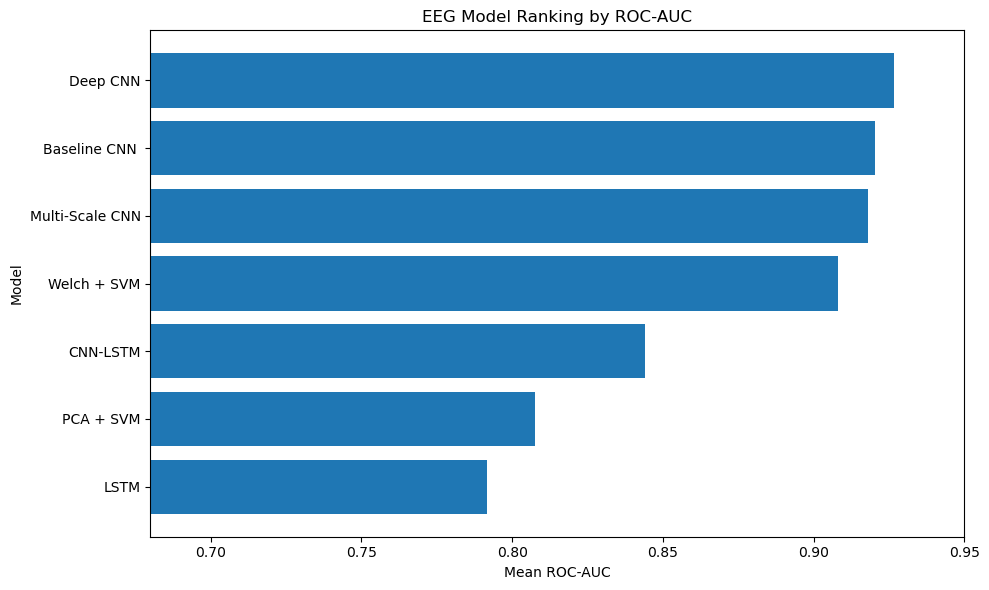

In [ ]:
roc_plot_df = plot_df.sort_values("roc_auc", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(
    roc_plot_df["model_name"],
    roc_plot_df["roc_auc"]
)

plt.title("EEG Model Ranking by ROC-AUC")
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Model")
plt.xlim(0.68, 0.95)


plt.tight_layout()
plt.show()

## Final Interpretation 

The baseline CNN architecture achieved the strongest overall balance between accuracy, F1-score, and ROC-AUC, with only modest improvements observed from more complex multi-scale or deeper architectures. These results suggest that EEG classification in this setting is primarily driven by localized temporal patterns that can be effectively captured through convolutional feature extraction. Increasing architectural complexity through deeper networks or recurrent sequence modeling did not consistently improve generalization performance, indicating limited benefit from hierarchical or long-range temporal representations for this dataset. 

